## Load and apply inference models
This notebook loads trained inference models from the outputs of `cmass.infer.train`, plots their prediction performance, and applies them to new test data.

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os
from os.path import join
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
mpl.style.use('../../style.mcstyle')   # noqa
import numpy as np
import torch
import seaborn as sns
import pandas as pd
import warnings
from tqdm import tqdm

from tools import torch_device

device = torch_device()

# Suppress warnings
warnings.filterwarnings('ignore')

Duplicate key in file '../../style.mcstyle', line 16 ('font.family: serif')


CUDA is not available. Using CPU.


## Examine abacus cosmologies

In [2]:
wdir = '/anvil/scratch/x-mho1/cmass-ili'
tabpath = join(wdir, 'scratch', 'abacus_custom_table.csv')
cosm = pd.read_csv(tabpath)

Omega_m = cosm['omega_cdm'] + cosm['omega_b'] + cosm['omega_ncdm']
Omega_b = cosm['omega_b']
h = cosm['h']
n_s = cosm['n_s']
sigma8 = cosm['sigma8_m']

# rescale to capital Omega
Omega_m /= h**2
Omega_b /= h**2

idx_lcdm = np.argwhere(cosm['LCDM'] == 'y').flatten().tolist()
idx_mnu = np.argwhere(cosm['Massive Neutrinos'] == 'y').flatten().tolist()
idx_simple = list(set(idx_lcdm) - set(idx_mnu))

print('LCDM:', idx_lcdm)
print('Mnu>0:', idx_mnu)
print('LCDM & Mnu=0:', idx_simple)

# cosm

LCDM: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 53, 54, 55, 56, 57, 58, 59, 60, 61, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]
Mnu>0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 33, 39, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118]
LCDM & Mnu=0: [32, 34, 35, 36, 37, 38, 40, 30, 31]


## Load a model

In [30]:
wdir = '/anvil/scratch/x-mho1/cmass-ili'
cosmonames = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$']
hodnames = [r'$\alpha$', r'$\log M_0$', r'$\log M_1$',
            r'$\log M_{\min}$', r'$\sigma_{\log M}$']
names = cosmonames  # +hodnames

# Specify model configuration
nbody = 'abacuslike'
sim = 'fastpm_hodzbias'
save_dir = join(wdir, nbody, sim, 'models')

# Specify data dtype
# tracer = 'halo'
tracer = 'galaxy'
# summaries = ['zPk0', 'zPk2', 'zPk4',  'zQk0']
summaries = ['Pk0', 'Pk2', 'Pk4', 'Qk0']
summary = '+'.join(summaries)
kmin, kmax = 0.0, 0.4
modelpath = join(save_dir, tracer, summary, f'kmin-{kmin}_kmax-{kmax}')
print(
    f'Loading model: nbody={nbody}, sim={sim}, tracer={tracer}, \n\tsummary={summary}, kmin={kmin}, kmax={kmax}')
print('\n'.join(os.listdir(modelpath)))

Loading model: nbody=abacuslike, sim=fastpm_hodzbias, tracer=galaxy, 
	summary=Pk0+Pk2+Pk4+Qk0, kmin=0.0, kmax=0.4
x_val.npy
posterior.pkl
true_logprobs.npy
ids_test.npy
plot_hyperparam_dependence.jpg
theta_train.npy
plot_coverage.jpg
theta_test.npy
x_test.npy
nets
plot_true_logprobs.jpg
ids_train.npy
theta_val.npy
ranks_histogram.jpg
plot_single_posterior.jpg
x_train.npy
plot_TARP.jpg
optuna_study.db
plot_predictions.jpg
ids_val.npy
posterior_samples.npy


In [31]:
# Load predictions
xtest = np.load(join(modelpath, 'x_test.npy'))
ytest = np.load(join(modelpath, 'theta_test.npy'))
samps = np.load(join(modelpath, 'posterior_samples.npy'))
percs = np.percentile(samps, [16, 50, 84], axis=0)

yrange = np.stack([
    ytest.min(axis=0),
    ytest.max(axis=0)
], axis=1)

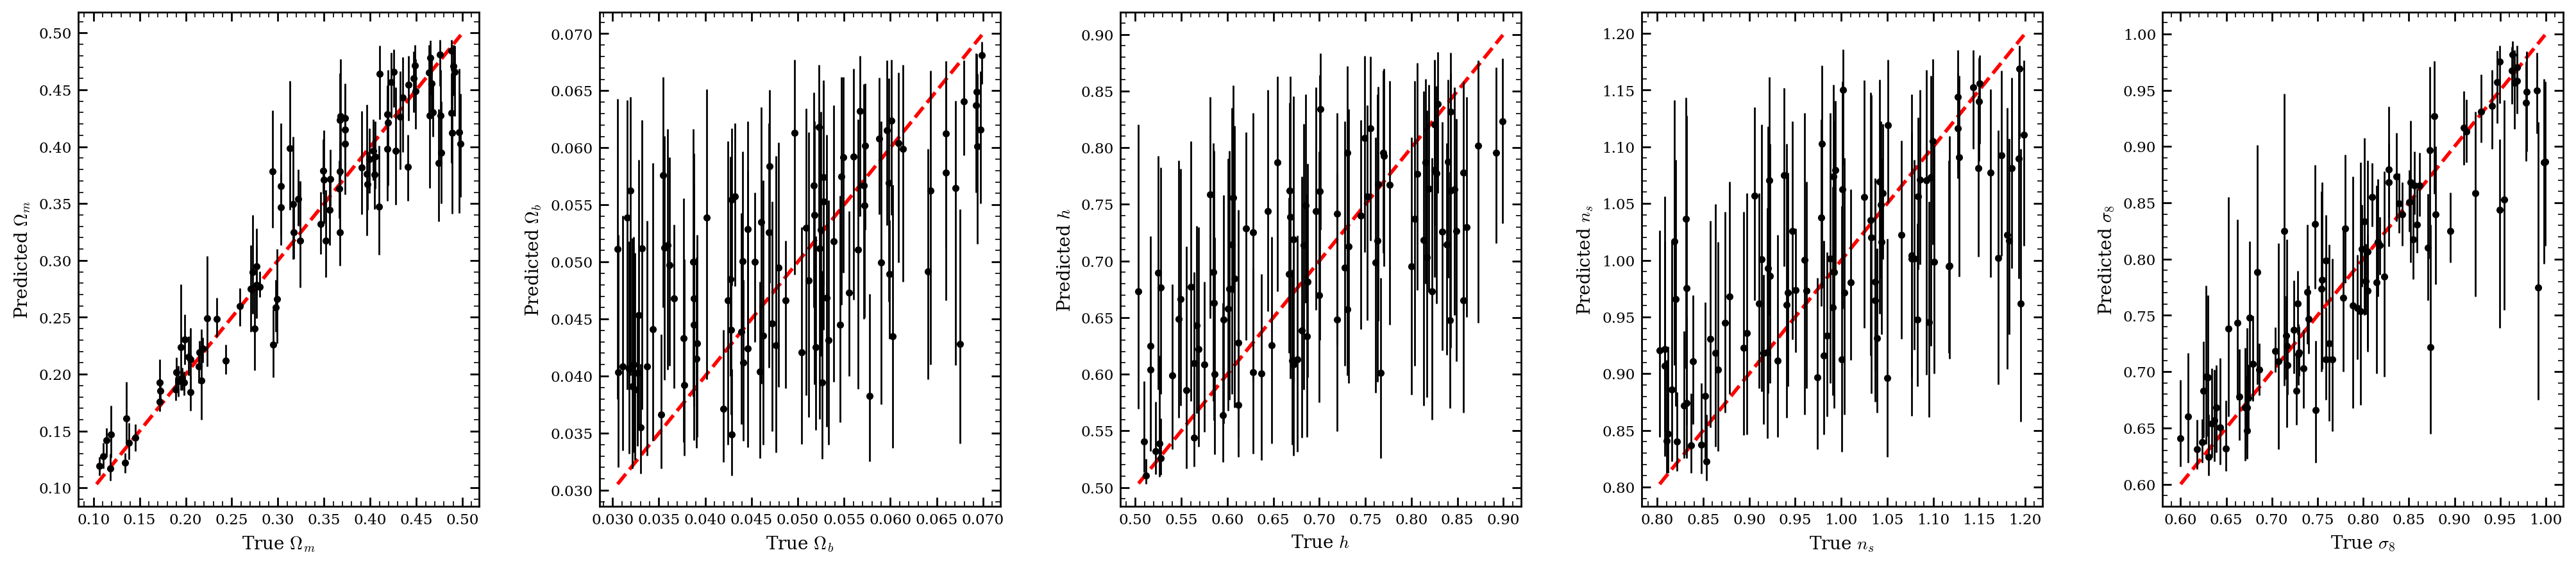

In [32]:
ss = 10

N = len(names)
H, W = N//5, 5
f, axs = plt.subplots(H, W, figsize=(5*W, 5*H), gridspec_kw=dict(wspace=0.3))
axs = axs.flatten()

for i, ax in enumerate(axs):
    if i >= N:
        ax.axis('off')
        continue
    ax.plot(yrange[i], yrange[i], 'r--')
    ax.plot(ytest[::ss, i], percs[1, ::ss, i], 'k.')
    ax.errorbar(ytest[::ss, i], percs[1, ::ss, i], yerr=[percs[1, ::ss, i]-percs[0, ::ss, i],
                percs[2, ::ss, i]-percs[1, ::ss, i]], fmt='none', ecolor='k', elinewidth=1)
    ax.set(xlabel=f'True {names[i]}', ylabel=f'Predicted {names[i]}')

In [33]:
# Load literature data
lit_path = join(wdir, 'literature', 'processed')

# SimBIG zPk024
filename = join(lit_path, 'simbig_pk.csv')
simpk = pd.read_csv(filename)
simpk.columns = names
simpk['Model'] = 'SimBIG zPk024'

# SimBIG zQk0
filename = join(lit_path, 'simbig_bk.csv')
simbk = pd.read_csv(filename)
simbk.columns = names
simbk['Model'] = 'SimBIG zQk0'

# print(simpk.shape, simbk.shape)
# simbk

In [34]:
if 'nbar' not in summaries:
    raise ValueError('Cell only works for nbar summary')

nbar_CMASS = np.log10(3e-4)
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

W = 3
H = len(names) // W + (len(names) % W > 0)

f, axs = plt.subplots(H, W, figsize=(5*W, 3*H),
                      sharex=True,
                      gridspec_kw=dict(hspace=0.1))
axs = axs.flatten()
for i, ax in enumerate(axs):
    if i >= len(names):
        ax.axis('off')
        continue
    ax.plot(xtest[:, -1], samps.std(axis=0)[:, i], '.', alpha=0.5)
    ax.axvline(nbar_CMASS, color='r', ls='--', label='CMASS')
    ax.axhline(sb_pkstd[i], color='C2', ls='--', label='SimBIG Pk')
    ax.axhline(sb_bkstd[i], color='C4', ls='--', label='SimBIG Bk')
    ax.set_ylabel(f'Posterior STD[{names[i]}]')
    ax.set_ylim(0)
    if i == len(names) - 1:
        ax.set_xlabel(r'$\log_{10}\left[\bar{n}\, ({\rm Mpc}/h)^{-3}\right]$')
    if i == 0:
        ax.legend()

f.suptitle(
    f'{tracer} ' + '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$')

ValueError: Cell only works for nbar summary

In [35]:
from tools import load_posterior

posterior = load_posterior(modelpath)
for p in posterior.posteriors:
    print(type(p.nde.flow))

<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>


100%|██████████| 20/20 [00:00<00:00, 508.41it/s]


[Text(0.5, 0, 'Epoch'), Text(0, 0.5, 'Log Probability')]

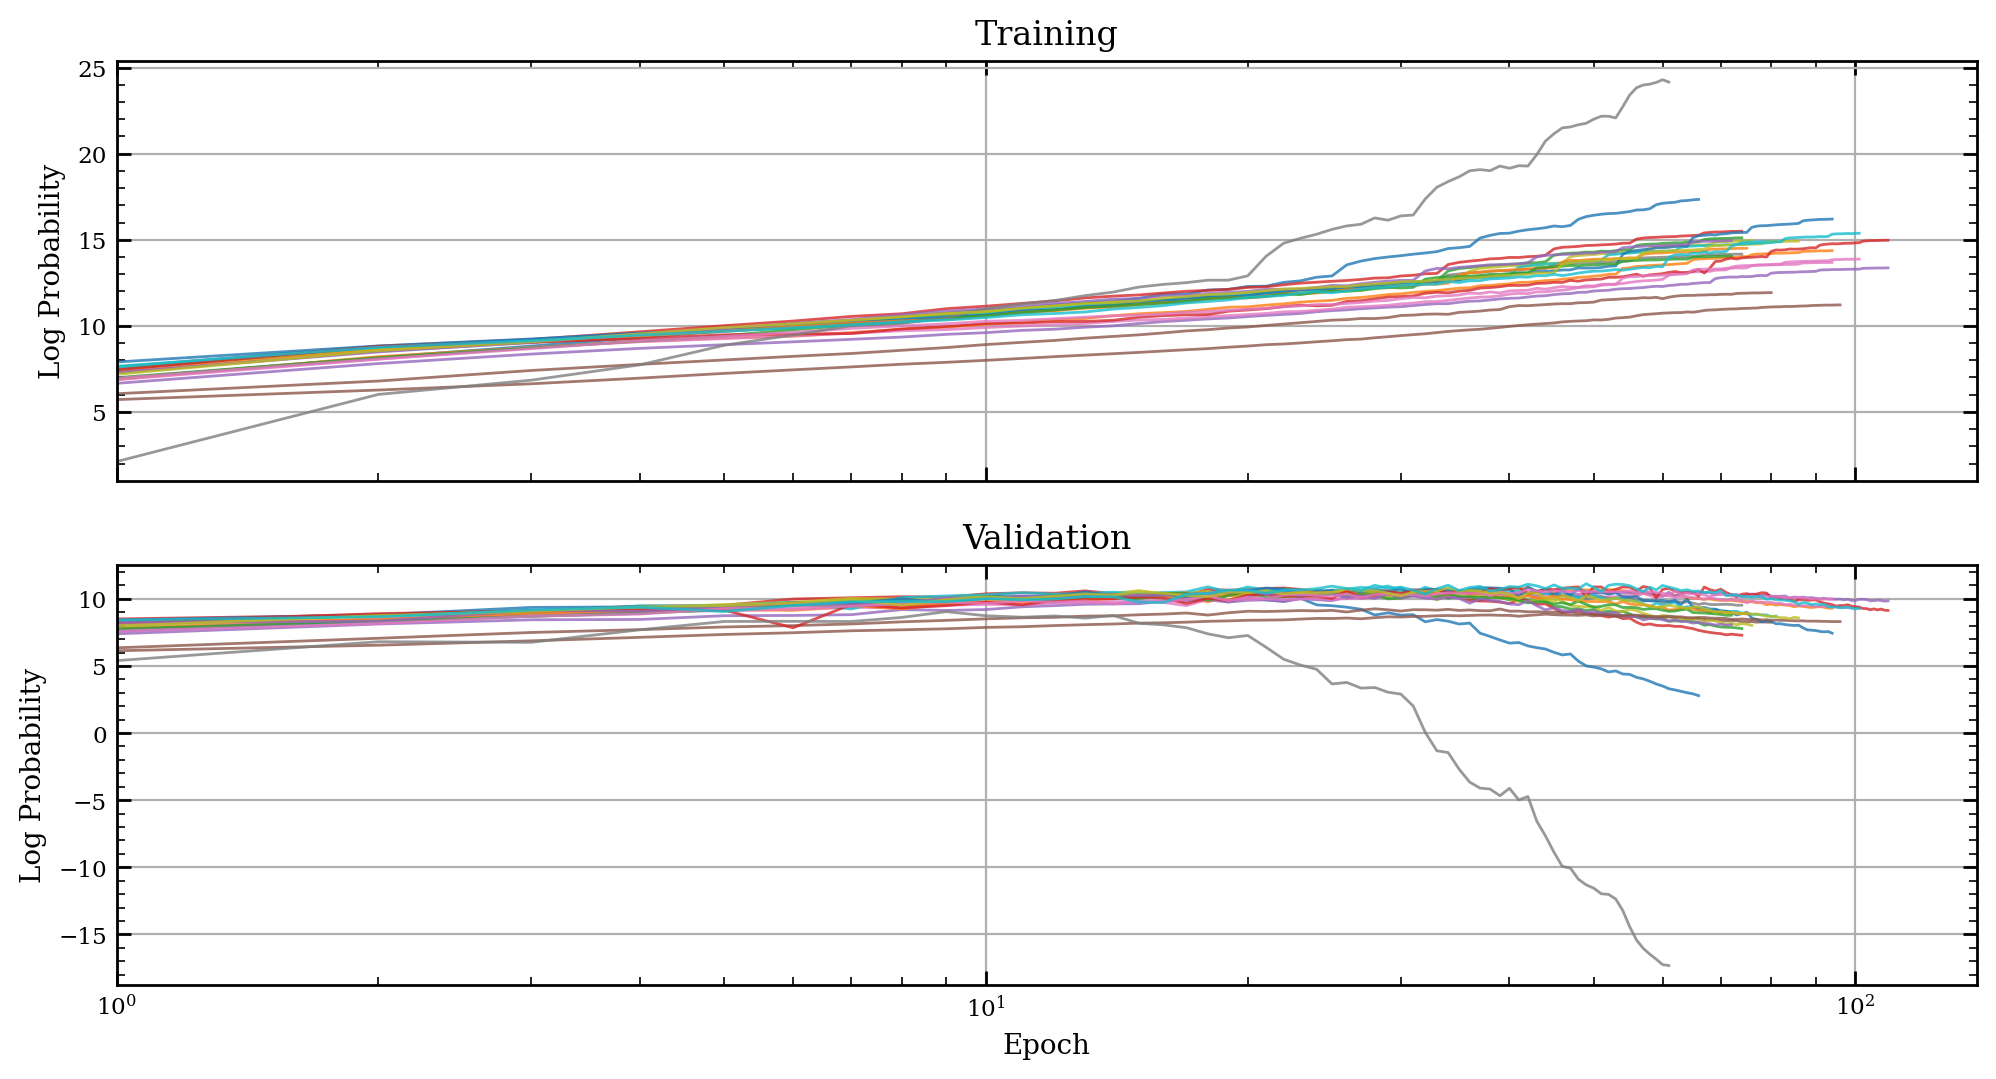

In [36]:
ss = 10

netpath = join(modelpath, 'nets')
netlist = os.listdir(netpath)

f, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for n in tqdm(netlist[::ss]):
    filepath = join(netpath, n, 'summary.json')
    if not os.path.exists(filepath):
        continue
    with open(filepath, 'r') as f:
        history = json.load(f)

    x_ = range(1, len(history[0]['training_log_probs'])+1)

    ax = axs[0]
    ax.plot(x_, history[0]['training_log_probs'], alpha=0.8, lw=1)

    ax = axs[1]
    ax.plot(x_, history[0]['validation_log_probs'], alpha=0.8, lw=1)

ax.semilogx()
ax.set_xlim(1)
# ax.set_ylim(-10, 20)

axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[0].grid()
axs[1].grid()

axs[0].set(ylabel='Log Probability')
axs[1].set(xlabel='Epoch', ylabel='Log Probability')

INFO:root:Sampling models with [248, 223, 216, 192, 191, 190, 189, 187, 186, 184] samples each.
Drawing 248 posterior samples: 490it [00:00, 15115.28it/s]            
Drawing 223 posterior samples: 440it [00:00, 7069.34it/s]             
Drawing 216 posterior samples: 430it [00:00, 13272.92it/s]            
Drawing 192 posterior samples: 100%|██████████| 192/192 [00:00<00:00, 11505.53it/s]
Drawing 191 posterior samples: 381it [00:00, 18290.37it/s]            
Drawing 187 posterior samples: 100%|██████████| 187/187 [00:00<00:00, 12520.91it/s]
Drawing 186 posterior samples: 357it [00:00, 20171.71it/s]            
Drawing 184 posterior samples: 365it [00:00, 13124.39it/s]            


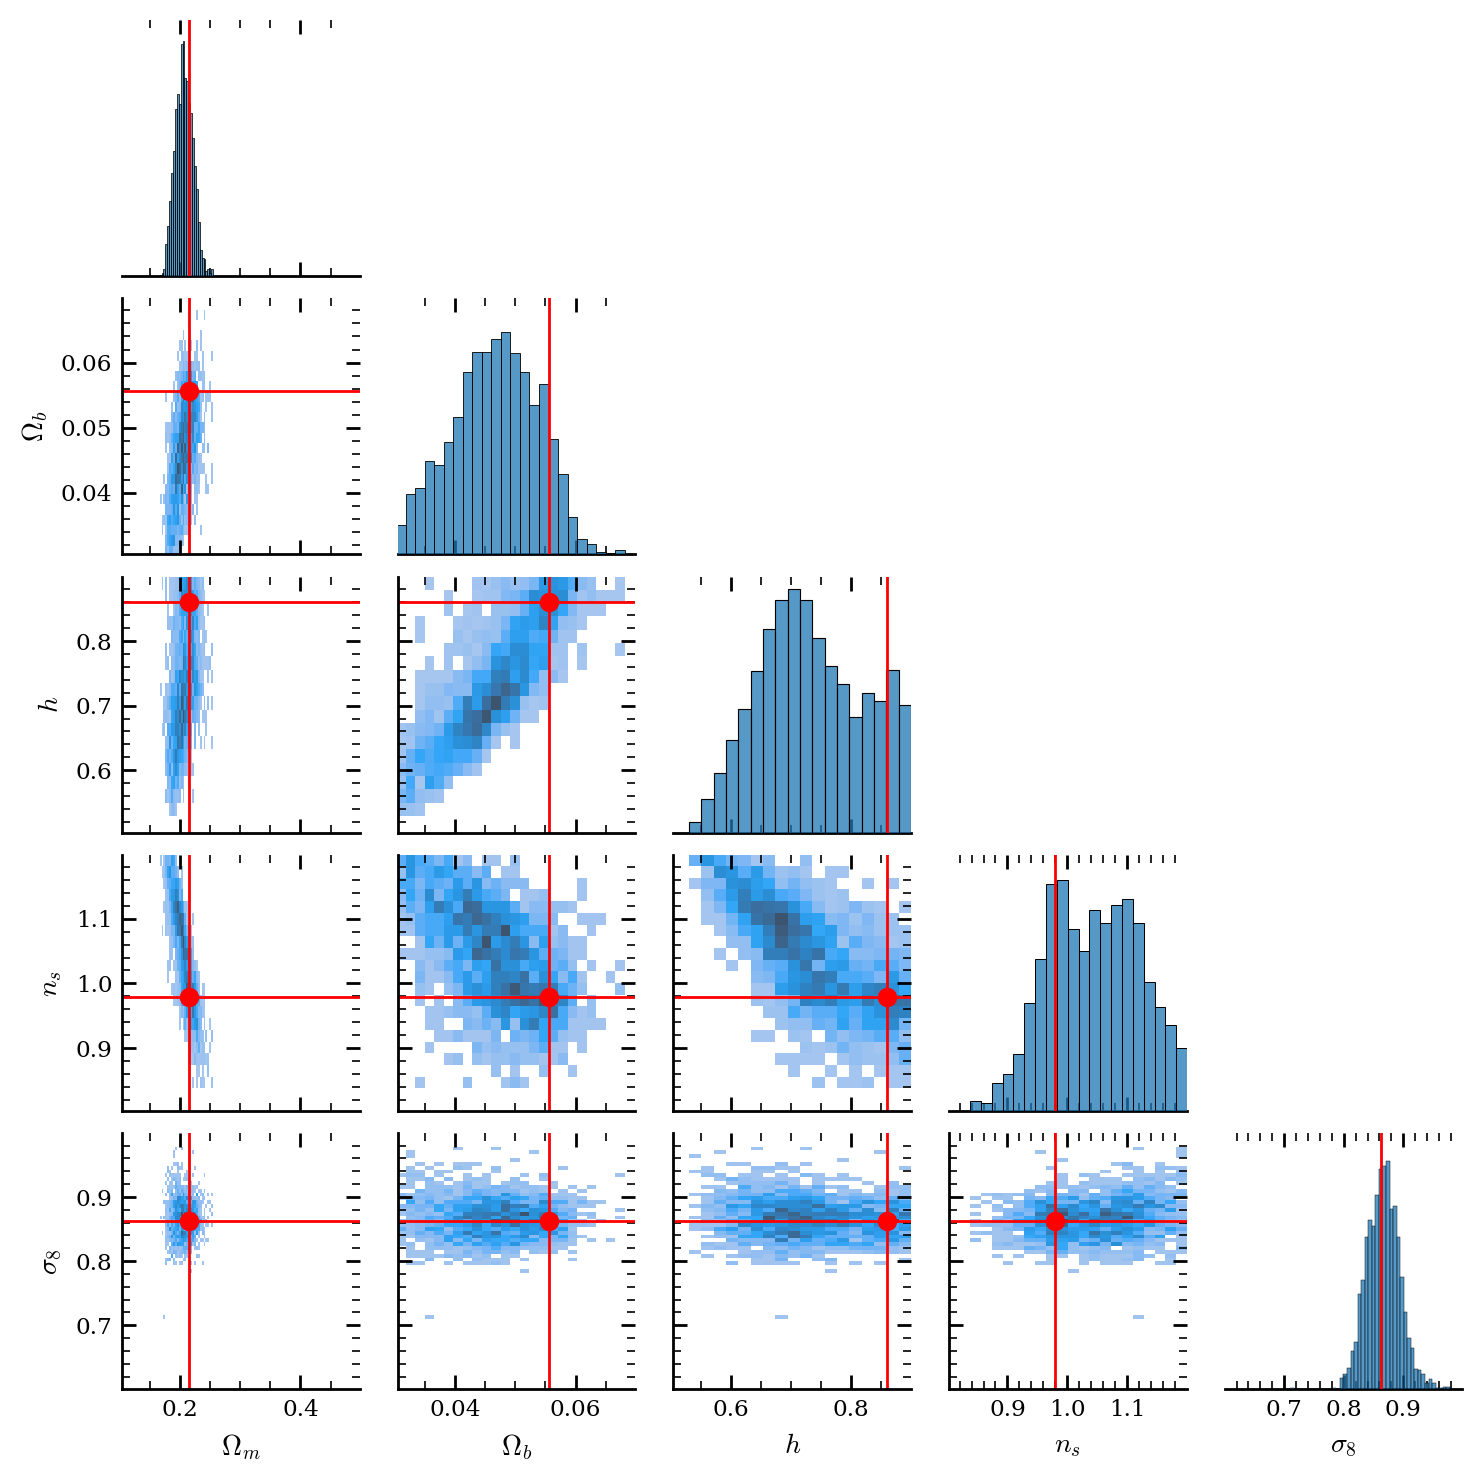

In [37]:
from tools import plot_true_vals, set_boundaries

# Predict on a random test point
ind = 0
x0 = torch.Tensor(xtest[ind]).to(device)
y0 = ytest[ind]
samp0 = posterior.sample(x=x0, shape=(2000,))
samp0 = pd.DataFrame(samp0, columns=names)

g = sns.pairplot(
    samp0,
    vars=names,
    kind='hist',
    corner=True,
    height=1.5
    # plot_kws={'alpha': 0.5, 'levels': [0.05, 0.36, 1], 'fill': True},  # for kde plot
)

plot_true_vals(g, y0, color='r', lw=1)
set_boundaries(g, yrange)

## Load an observed summary

In [38]:
# Load observed data
nbody = 'abacus'
sim = 'custom'
save_dir = join(wdir, nbody, sim, 'models')
modelpath = join(save_dir, tracer, summary, f'kmin-{kmin}_kmax-{kmax}')

xobs = np.load(join(modelpath, 'x_test.npy'))
yobs = np.load(join(modelpath, 'theta_test.npy'))
xid = np.load(join(modelpath, 'ids_test.npy'))

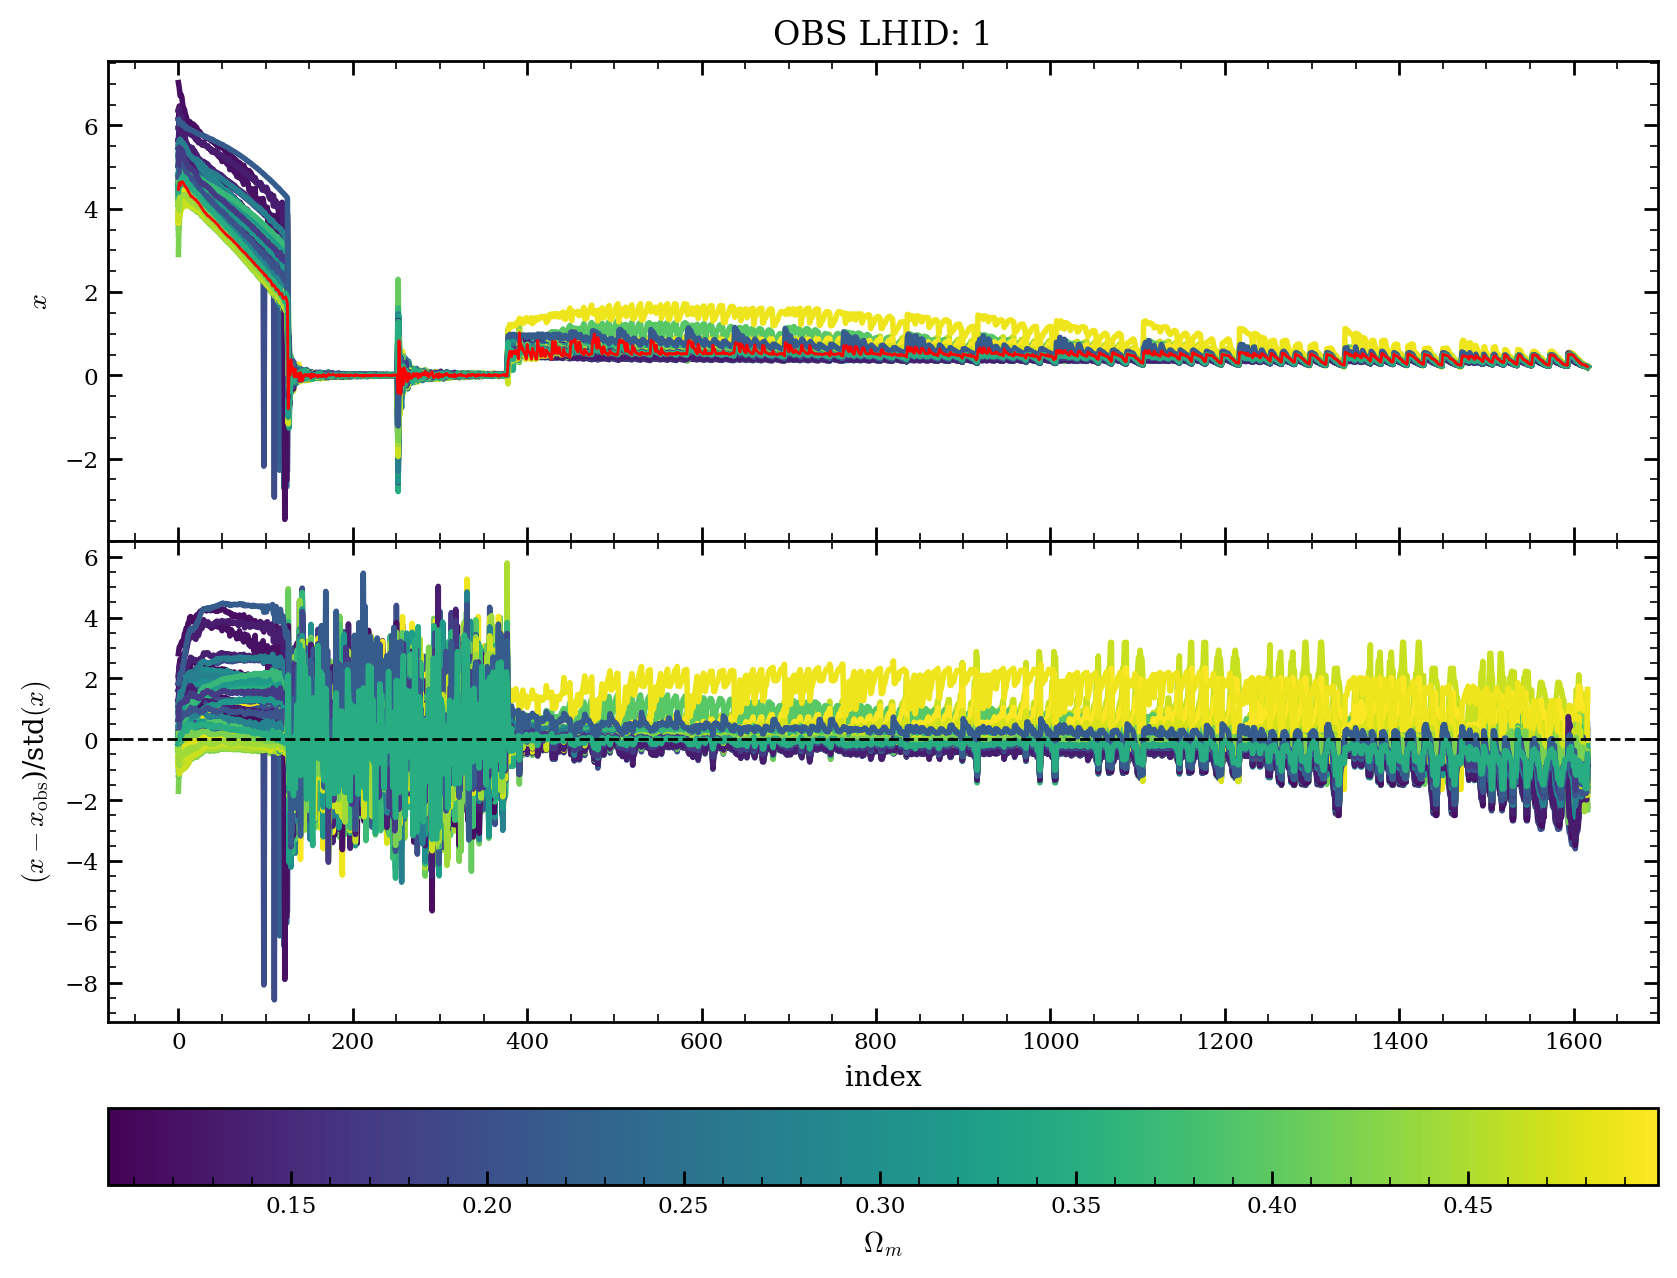

In [39]:
ss = 10
ind = 0

f, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                      gridspec_kw=dict(hspace=0., height_ratios=[1, 1]))

par = ytest[:, 0]
cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=par.min(), vmax=par.max())

ax = axs[0]
for i in range(0, len(xtest), ss):
    ax.plot(xtest[i], color=cmap(norm(par[i])))
ax.plot(xobs[ind], 'r-', lw=1)
ax.set(ylabel=r'$x$')
ax.set_title(f'OBS LHID: {xid[ind]}')

ax = axs[1]
for i in range(0, len(xtest), ss):
    ax.plot((xtest[i]-xobs[ind])/np.std(xtest, axis=0),
            color=cmap(norm(par[i])))
ax.axhline(0, c='k', ls='--', lw=1)
ax.set(xlabel='index', ylabel=r'$(x - x_{\rm obs}$)/std$(x)$')

cbar = f.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                  ax=axs, orientation='horizontal', pad=0.07)
cbar.set_label(r'$\Omega_m$')

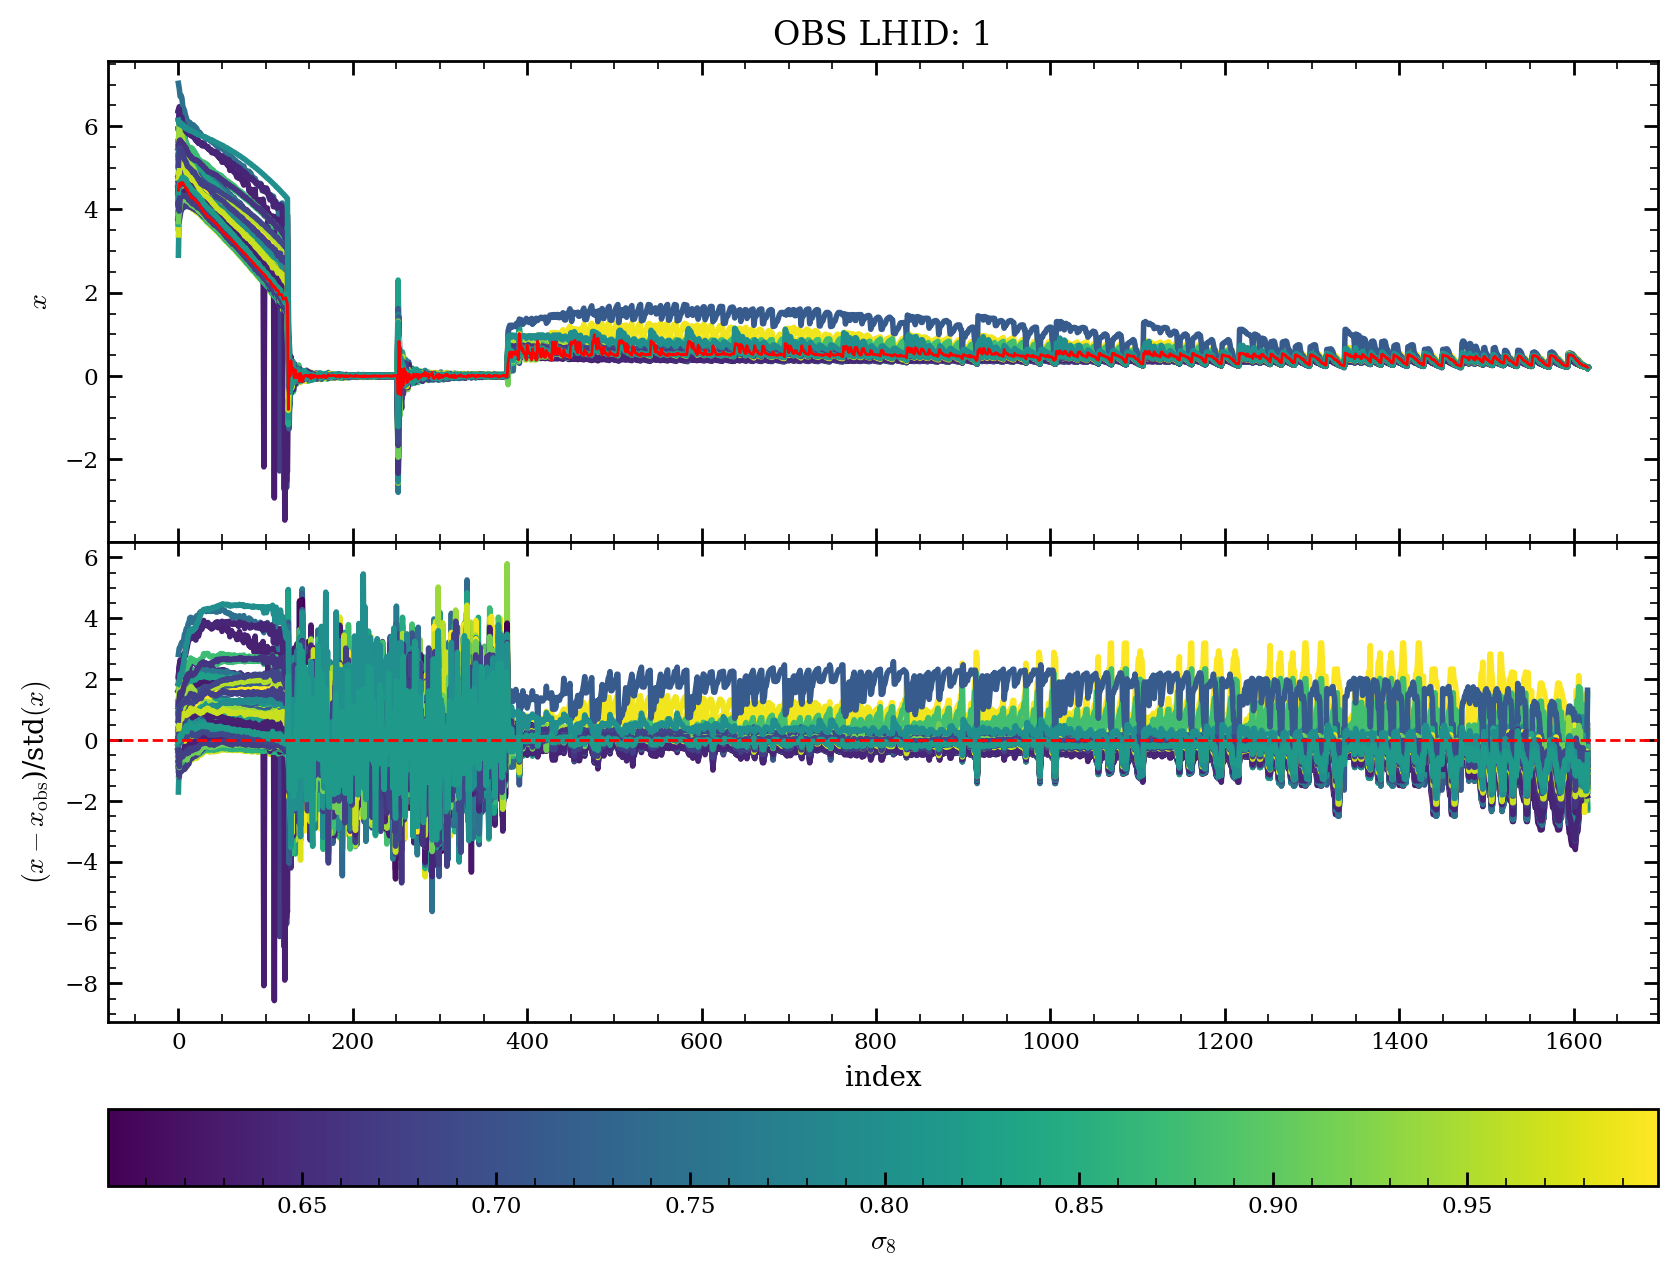

In [40]:
import matplotlib.colors as mcolors

ss = 10
ind = 0

f, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                      gridspec_kw=dict(hspace=0., height_ratios=[1, 1]))

par = ytest[:, 4]
cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=par.min(), vmax=par.max())

ax = axs[0]
for i in range(0, len(xtest), ss):
    ax.plot(xtest[i], color=cmap(norm(par[i])))
ax.plot(xobs[ind], 'r-', lw=1)
ax.set(ylabel=r'$x$')
ax.set_title(f'OBS LHID: {xid[ind]}')

ax = axs[1]
for i in range(0, len(xtest), ss):
    ax.plot((xtest[i]-xobs[ind])/np.std(xtest, axis=0),
            color=cmap(norm(par[i])))
ax.axhline(0, c='r', ls='--', lw=1)
ax.set(xlabel='index', ylabel=r'$(x - x_{\rm obs}$)/std$(x)$')

cbar = f.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                  ax=axs, orientation='horizontal', pad=0.07)
cbar.set_label(r'$\sigma_8$')

INFO:root:Sampling models with [248, 223, 216, 192, 191, 190, 189, 187, 186, 184] samples each.
Drawing 248 posterior samples: 494it [00:00, 15238.22it/s]            
Drawing 223 posterior samples: 100%|██████████| 223/223 [00:00<00:00, 6529.99it/s]
Drawing 216 posterior samples: 431it [00:00, 12822.34it/s]            
Drawing 192 posterior samples: 383it [00:00, 12971.62it/s]            
Drawing 191 posterior samples: 379it [00:00, 19282.40it/s]            
Drawing 190 posterior samples: 100%|██████████| 190/190 [00:00<00:00, 6552.36it/s]
Drawing 189 posterior samples: 375it [00:00, 12630.30it/s]            
Drawing 184 posterior samples: 100%|██████████| 184/184 [00:00<00:00, 12873.69it/s]


Text(0.5, 0.98, 'OBS LHID: 30, galaxy Pk0+Pk2+Pk4+Qk0, $k\\in[0.0,0.4]$,')

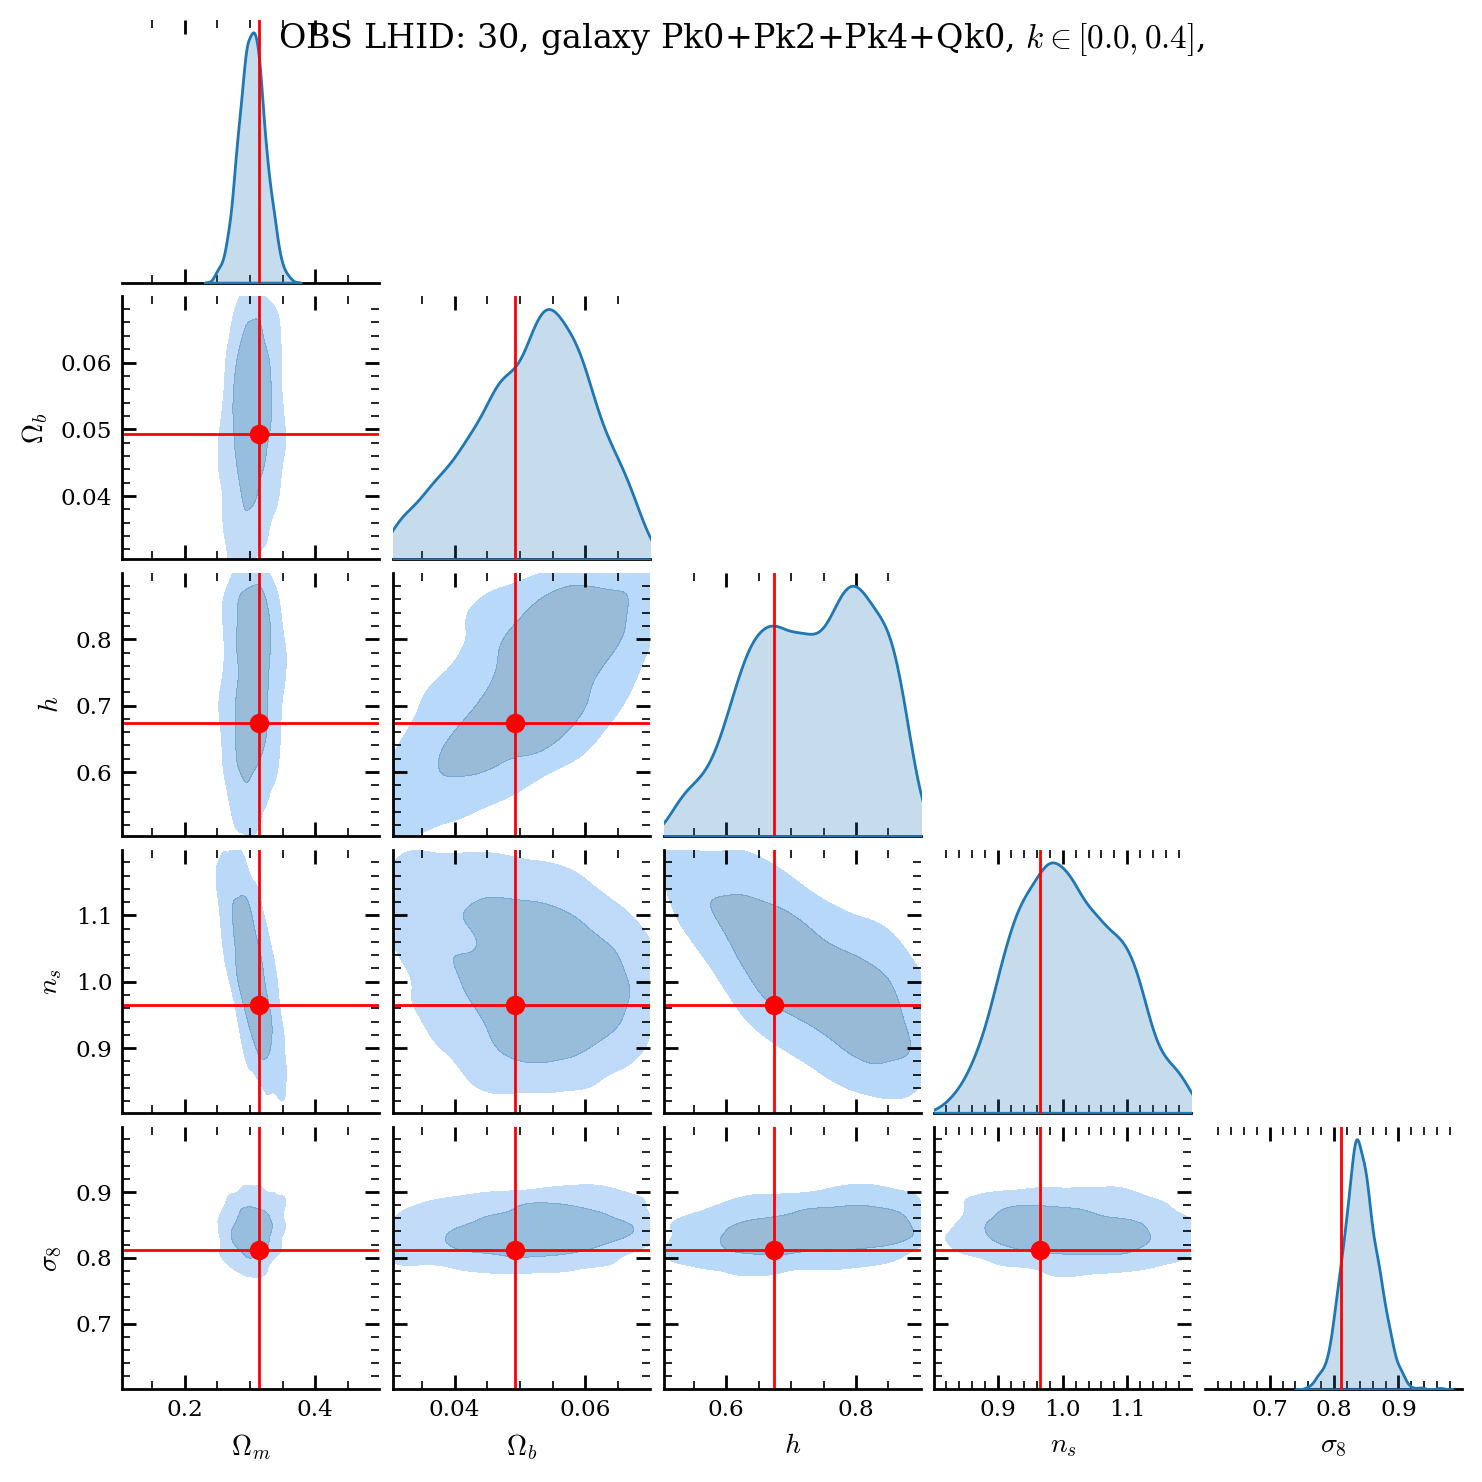

In [41]:
from tools import plot_true_vals, set_boundaries

# Predict on a random test point
ind = 27
samp0 = posterior.sample(x=xobs[ind], shape=(2000,)).to('cpu')
samp0 = pd.DataFrame(samp0, columns=names)


g = sns.pairplot(
    samp0,
    vars=names,
    kind='kde',
    plot_kws={'alpha': 0.5, 'levels': [
        0.05, 0.36, 1], 'fill': True, 'common_norm': False},
    corner=True,
    height=1.5
)
plot_true_vals(g, yobs[ind], color='r', lw=1)
set_boundaries(g, yrange)

g.fig.suptitle(f'OBS LHID: {xid[ind]}, {tracer} ' +
               '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$,')

## Predict on a suite of summaries

In [42]:
samps = []
for xin in tqdm(xobs):
    samp = posterior.sample(x=xin, shape=(
        1000,), show_progress_bars=False).to('cpu')
    samps.append(samp)
samps = np.array(samps)
trues = np.array(yobs)

100%|██████████| 114/114 [00:23<00:00,  4.75it/s]


In [43]:
def _get_first(arr):
    mask = np.isin(np.arange(len(arr)), np.sort(
        np.unique(arr, return_index=True)[1]))
    return mask


# get only the first occurrence of each unique value
first = _get_first(xid)

# LCDM w/ Mnu>0
flag1 = 'LCDM, w/ Mnu>0'
m1 = np.isin(xid, idx_lcdm) & np.isin(xid, idx_mnu) & first
# LCDM w/ Mnu=0
flag2 = 'LCDM, w/ Mnu=0'
m2 = np.isin(xid, idx_lcdm) & ~np.isin(xid, idx_mnu) & first
# No cuts
flag3 = ''
m3 = np.ones(len(xid), dtype=bool) & first

ms = [m1, m2, m3]
flags = [flag1, flag2, flag3]
m, flag = m3, flag3

Text(0.5, 0.98, 'Pk0+Pk2+Pk4+Qk0, $k\\in[0.0,0.4]$, w/o prior correction')

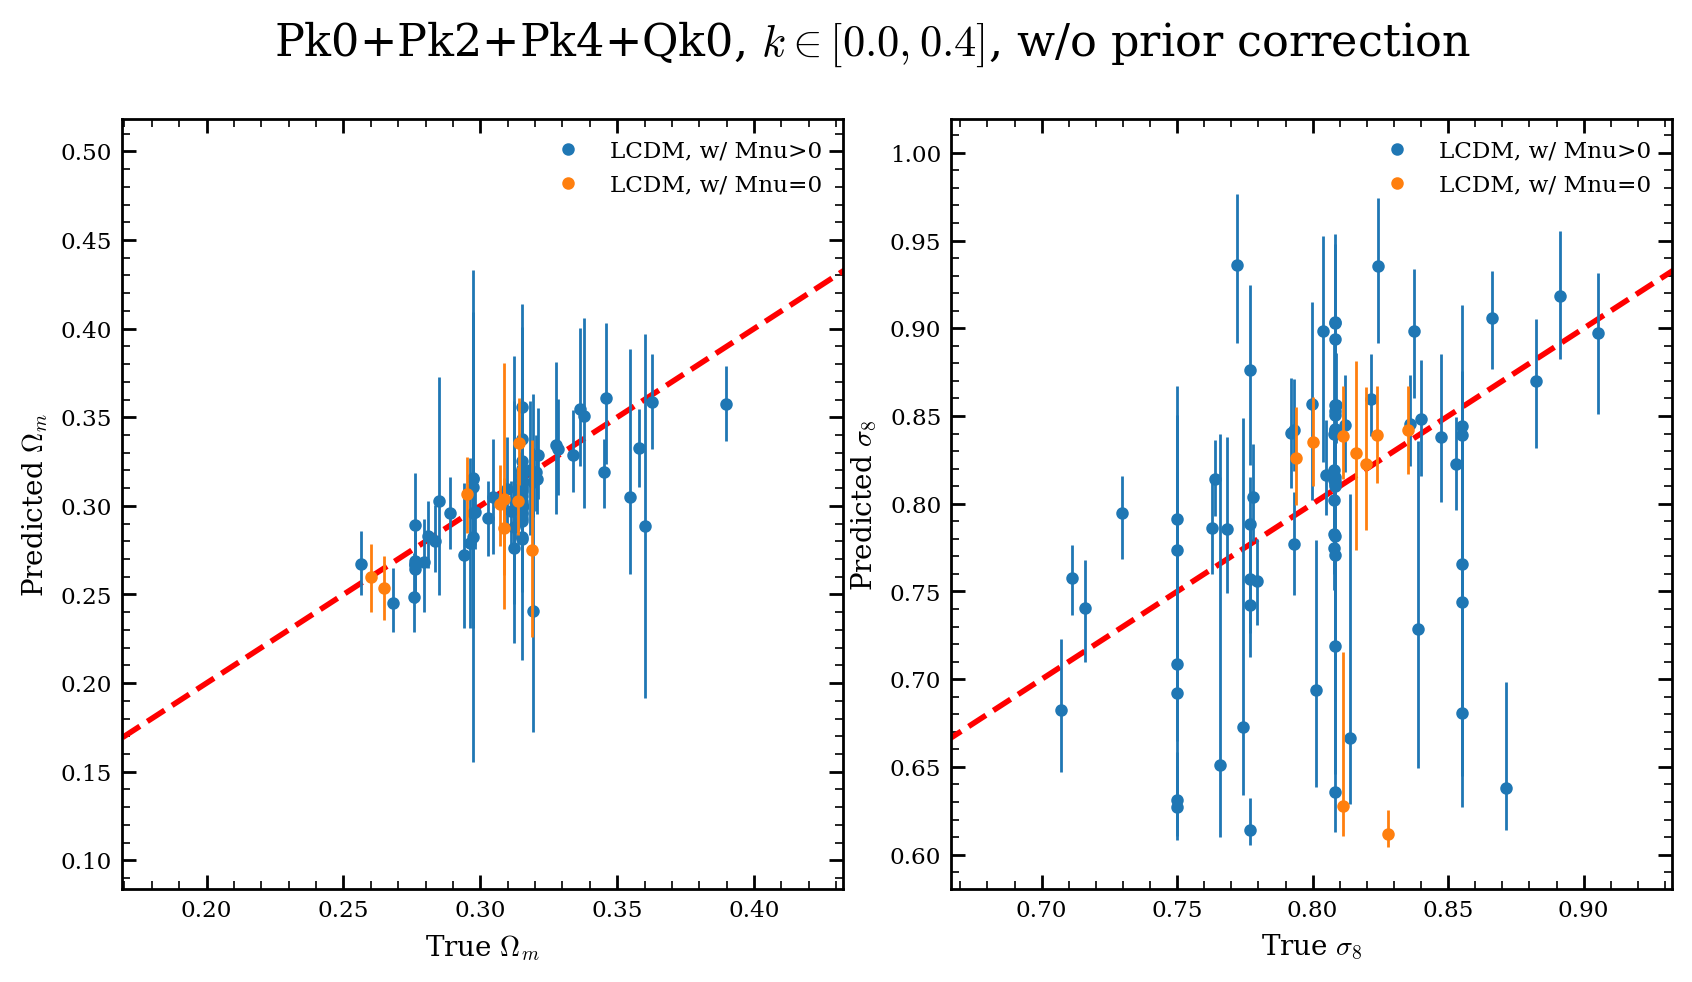

In [44]:
H, W = 1, 2
f, axs = plt.subplots(H, W, figsize=(5*W, 5*H), gridspec_kw=dict(wspace=0.15))
axs = axs.flatten()

for j, i in enumerate([0, 4]):
    ax = axs[j]
    ax.plot(yrange[i], yrange[i], 'r--')
    ax.set_xlim(yrange[i][0] + (yrange[i][1] - yrange[i][0]) / 6,
                yrange[i][1] - (yrange[i][1] - yrange[i][0]) / 6)
    # ax.set_ylim(yrange[i])
    ax.set(xlabel=f'True {names[i]}', ylabel=f'Predicted {names[i]}')
    for k, m in enumerate(ms[:2]):
        percs = np.percentile(samps[m, :, i], [50, 16, 84], axis=1)
        ax.plot(trues[m, i], percs[0], '.',
                color=f'C{k}', markersize=7, label=flags[k])
        ax.errorbar(trues[m, i], percs[0], yerr=[percs[0]-percs[1],
                    percs[2]-percs[0]], fmt='none', color=f'C{k}', elinewidth=1)
    ax.legend()

f.suptitle(
    '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$,'
    ' w/o prior correction',
    fontsize=16)

## Scratch